## 1. Import libraries & packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

## 2. Load the dataset into a dataframe

In [2]:
df=pd.read_csv('data/raw/train.csv')
df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## 3. Bi-variate Analysis

### 3.1 Categorical Feature Vs. Categorical Target

#### 3.1.1 Plot the relation between **Tyre Compound** & **PitNextLap**

<Axes: xlabel='Compound', ylabel='count'>

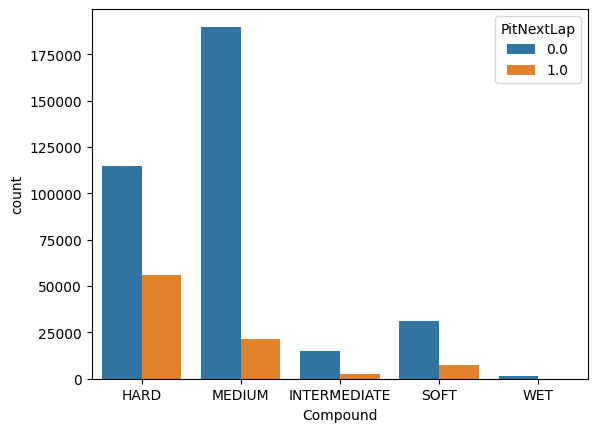

In [ ]:
sb.countplot(data=df, x='Compound', hue='PitNextLap')
plt.show()

- **Counplot** gives us a vague idea of data distribution but since i am trying to plot the relation between two categorical columns.
- I shall plot the distribution of proportions and normalize it in the same scale.

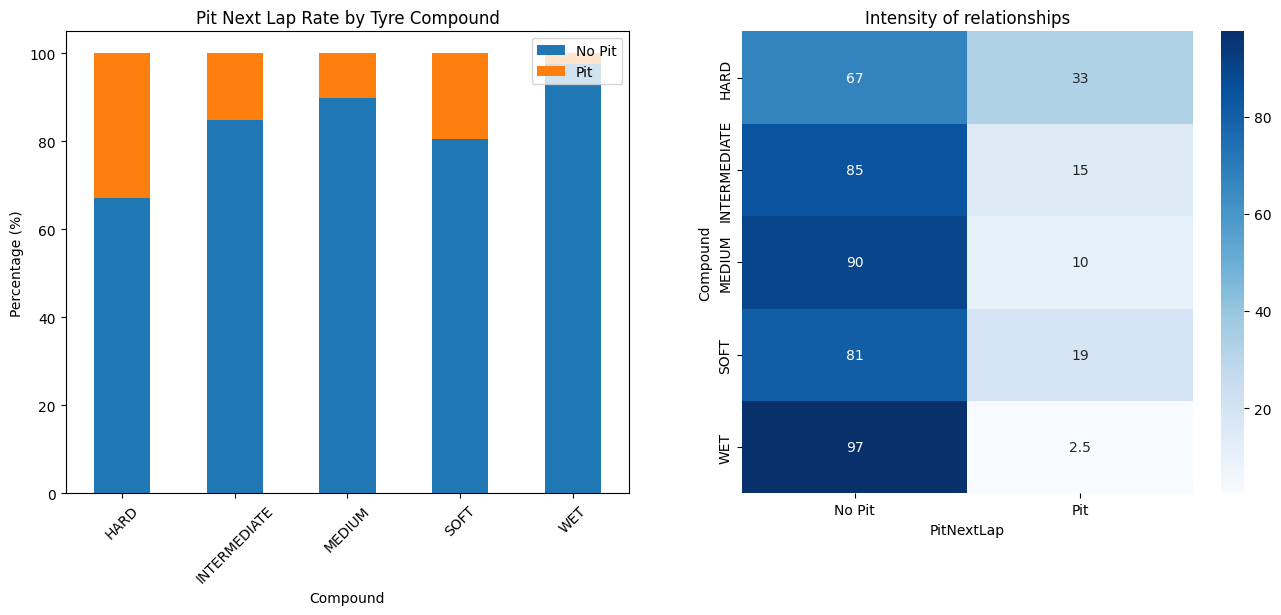

In [65]:
# Proportional grouped bar
fig, axes = plt.subplots(1,2, figsize=(16,6))

ct = pd.crosstab(df['Compound'], df['PitNextLap'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title('Pit Next Lap Rate by Tyre Compound')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['No Pit', 'Pit'], loc='upper right')

sb.heatmap(ct,annot=True,cmap='Blues',ax=axes[1])
axes[1].set_title("Intensity of relationships")
axes[1].set_xticklabels(["No Pit","Pit"])
plt.show()

***Observations:-***
- The HARD compound tires have more pit next lap rate as roughly 35% of F1 players running with HARD tire compounds performed a pit.
- The players running with INTERMEDIATE & SOFT tire compounds have roughly same pit rate with SOFT tire compounds leading by just a small margin, indicating that SOFT tire compounds wear away slightly early than intermediate ones which is correct.
- The MEDIUM compound tires performed well according to the expectations from it. It has lower pit rate than INTERMEDIATE & SOFT tires but higher than WET tires.
- The WET tire compound has the lowest pit rate among all compounds, possibly due to wet track or weather conditions which allowed the driver to cover more laps before requiring any pit.

#### 3.1.2 Relationship Between Race **Year** and **Next-Lap Pit** Decisions

Text(0.5, 0, 'Year')

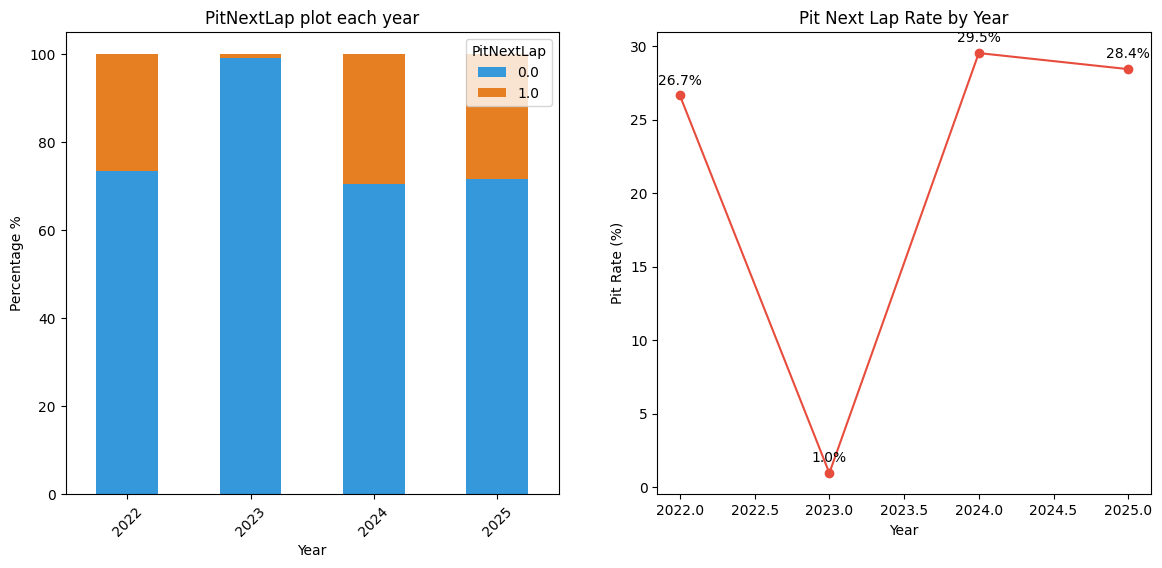

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(14,6))

ct = pd.crosstab(df['Year'], df['PitNextLap'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, color=['#3498db', '#e67e22'], ax=axes[0])
axes[0].set_title("PitNextLap plot each year")
axes[0].set_ylabel("Percentage %")
axes[0].set_xlabel("Year")
axes[0].tick_params(axis='x',rotation=45)

pit_rate = df.groupby('Year')['PitNextLap'].mean() * 100

for x,y in (zip(pit_rate.index,pit_rate.values)):
    axes[1].annotate(f'{y:.1f}%', # print the value
                    (x,y), # where to print the value, provide the co-ordinates
                    textcoords='offset points', # as an offset measured in screen points from the marker.
                    xytext=(0,8),
                    ha='center')

pit_rate.plot(kind='line', marker='o', color='#e74c3c',ax=axes[1])
axes[1].set_ylabel('Pit Rate (%)')
axes[1].set_title('Pit Next Lap Rate by Year')
axes[1].set_xlabel("Year")
plt.show()

***Observations:-***
- The pit next lap rate has been almost consistent from the year 2022 to 2025 except just one year; 2023.

- Year 2023 has the lowest pit rate among all 4 years of data, possibly due to policy changes in f1 race or due to drivers following a particular strategy of less pitting.

#### 3.1.3 Relationship Between **Current Pit Stops** and **Next-Lap Pit** Decisions

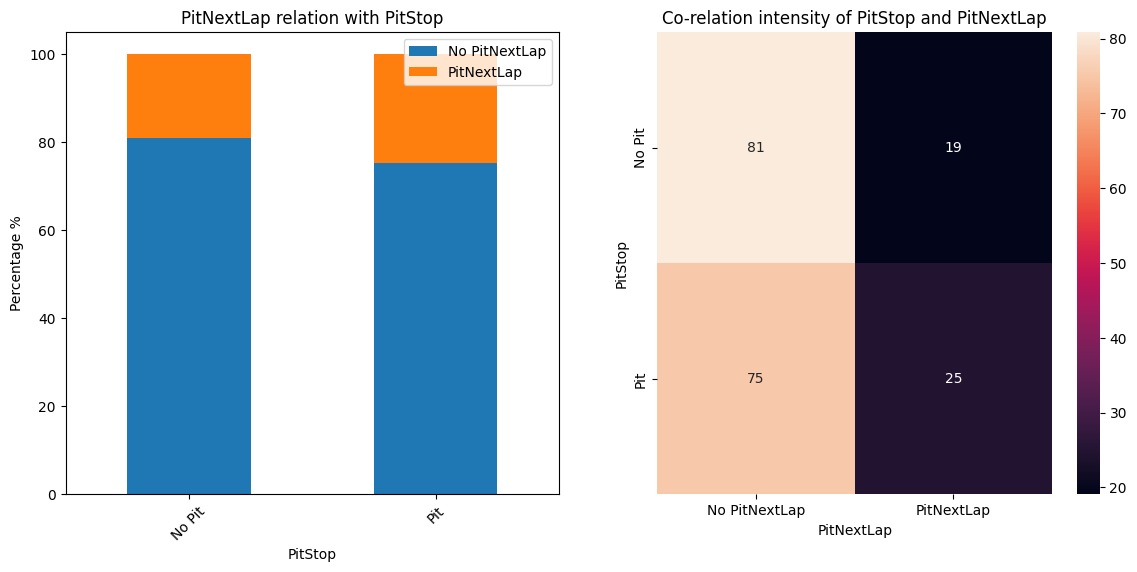

In [66]:
fig, axes = plt.subplots(1,2,figsize=(14,6))

cross_tab = pd.crosstab(df['PitStop'],df['PitNextLap'],normalize='index') * 100
cross_tab.plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title("PitNextLap relation with PitStop")
axes[0].set_ylabel("Percentage %")
axes[0].set_xticklabels(['No Pit','Pit'])
axes[0].tick_params(axis='x',rotation=45)
axes[0].legend(['No PitNextLap', 'PitNextLap'], loc='upper right')

sb.heatmap(cross_tab,annot=True,ax=axes[1])
axes[1].set_title("Co-relation intensity of PitStop and PitNextLap")
axes[1].set_yticklabels(['No Pit','Pit'])
axes[1].set_xticklabels(['No PitNextLap','PitNextLap'])
plt.show()


***Observations:-***
- It can be observed from both the graphs that, the chances of pitting reduces slightly when the driver doesn't perform a pit stop in the current lap.
- Also the positive pitting in the current lap , only slightly increases the chances from 19% to 25% that the driver will perform the Pit in the next lap.
- Therefore, there isn't a strong co-relation between the two attributes that can be a standalone factor in deriving out conclusions from it.

#### 3.1.4 Relationship between **Stint** & **Next-Lap Pit** Decisions

- In Formula 1, a **STINT** signifies the continuous period a car spends on track between leaving the pit lane (or starting the race) and its next pit stop. The **stint** number simply tracks how many of these intervals a driver has completed in a race.
- A new **stint** is started by a pitstop. 2 stints will mean 1 pitstop, 3 stints will require 2 pitstops and so on.

Text(0.5, 1.0, 'Percentage of Stint with respect to PitNextLap')

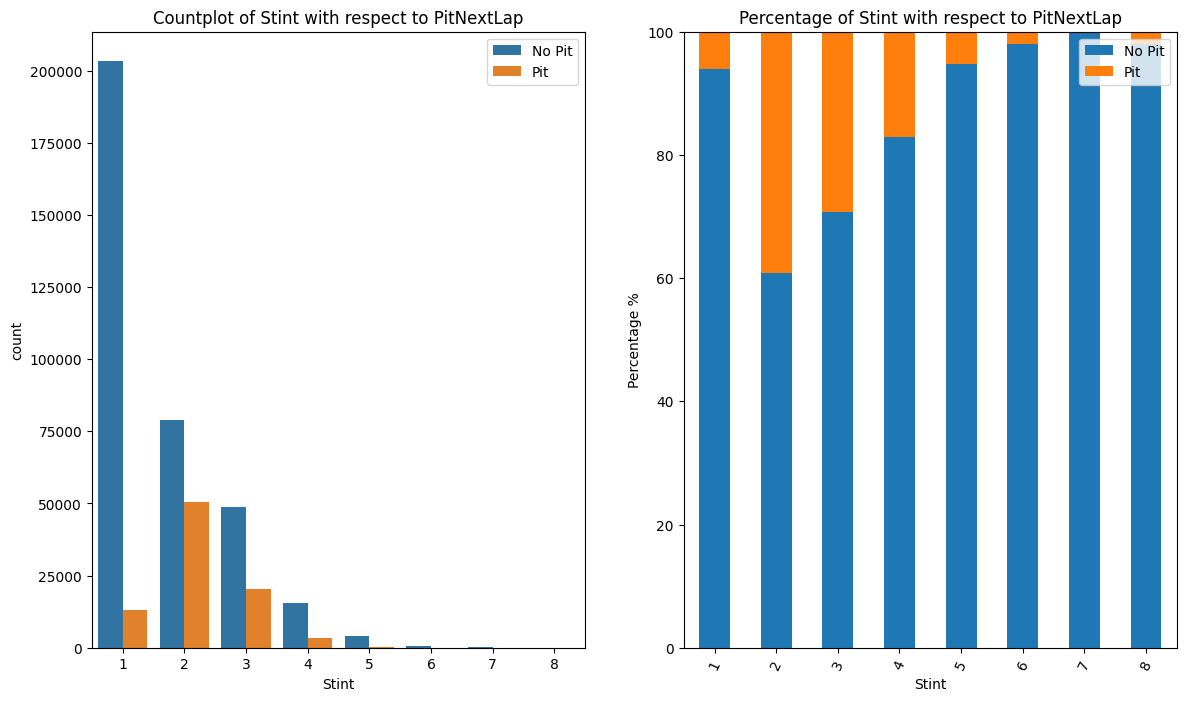

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(14,8))
fig
sb.countplot(data=df,x='Stint',hue='PitNextLap',ax=axes[0])
axes[0].set_title("Countplot of Stint with respect to PitNextLap")
axes[0].legend(['No Pit','Pit'])

ct= pd.crosstab(df['Stint'],df['PitNextLap'],normalize='index') * 100
#normalize the values means, dividing the class occurence by total number of total class

ct.plot(kind='bar',stacked=True,ax=axes[1])
axes[1].legend(['No Pit','Pit'],loc='upper right')
axes[1].set_ylabel("Percentage %")
axes[1].tick_params(axis='x',rotation=65)
axes[1].set_title("Percentage of Stint with respect to PitNextLap")
plt.show()

***Observations:-***
- It can be clearly observed from the graph that during the initial Stint (1) , only 20% of the drivers performed the Pit Stop i.e. just after one lap of the beginning of the race.
- As the race proceeds, 60% of the drivers didn't pit while 40% of them pit in Stint (2).
- At Stint (3), only 70% of the drivers didn't pit, while 30% of them pit.

- Therefore, it can be clearly concluded that as the stint increases, the pit rate decreases with some exception in stint 8. Possibly there are some outliers, will check in different plot. 

### 3.2 Numerical Feature Vs. Categorical Target

#### 3.2.1 Relationship between **Current Lap Number** and **Next-Lap Pit** Decisions

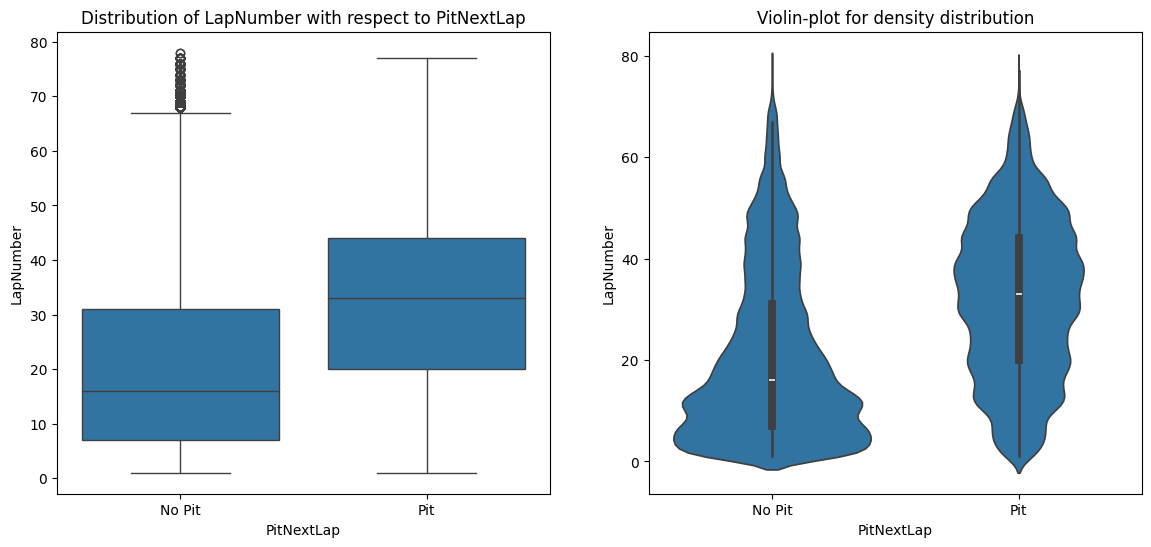

In [13]:
fig, axes = plt.subplots(1,2, figsize=(14,6))

sb.boxplot(data=df,x='PitNextLap',y='LapNumber',ax=axes[0])
axes[0].set_title("Distribution of LapNumber with respect to PitNextLap")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No Pit","Pit"])

sb.violinplot(data=df,x="PitNextLap",y="LapNumber",ax=axes[1])
axes[1].set_title("Violin-plot for density distribution")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["No Pit","Pit"])
plt.show()


#### **LapNumber – Lap index within the race**

***Observations:-***

**1. Central Tendency & Spread**

- Pit laps have a higher median LapNumber (~33) vs No Pit (~17), suggesting pit stops are more likely to occur in the middle-to-later stages of a race.
- The IQR for Pit (~22–44) is wider and sits higher than No Pit (~10–30), indicating pit decisions are spread across a broader race window but skew later.

**2. Distribution Shape (Violin Plot)**

- No Pit has a massive dense bulge from laps 0–30, meaning the bulk of non-pit laps happen early in the race — drivers are simply not pitting in the opening phase.
- Pit violin is remarkably wide and evenly spread from ~15–60 laps, with multiple subtle bumps — this likely reflects multimodal pit strategy windows (lap 20–25 for early stoppers, lap 35–45 for medium strategy, later for one-stoppers).
- The bumpy/irregular shape of the Pit violin is particularly interesting — it hints at distinct strategic clusters rather than one smooth pit window.

**3. Outliers**

- No Pit has notable outliers above lap 70 — these are probably the final laps where no one pits regardless of tyre state.
- Pit has very few outliers, and its whiskers extend to ~77, meaning some pit stops do happen very late (likely under safety car or strategic overcuts).

#### 3.2.2 Relationship between **Tyre Life** and **Next-Lap Pit** Decisions

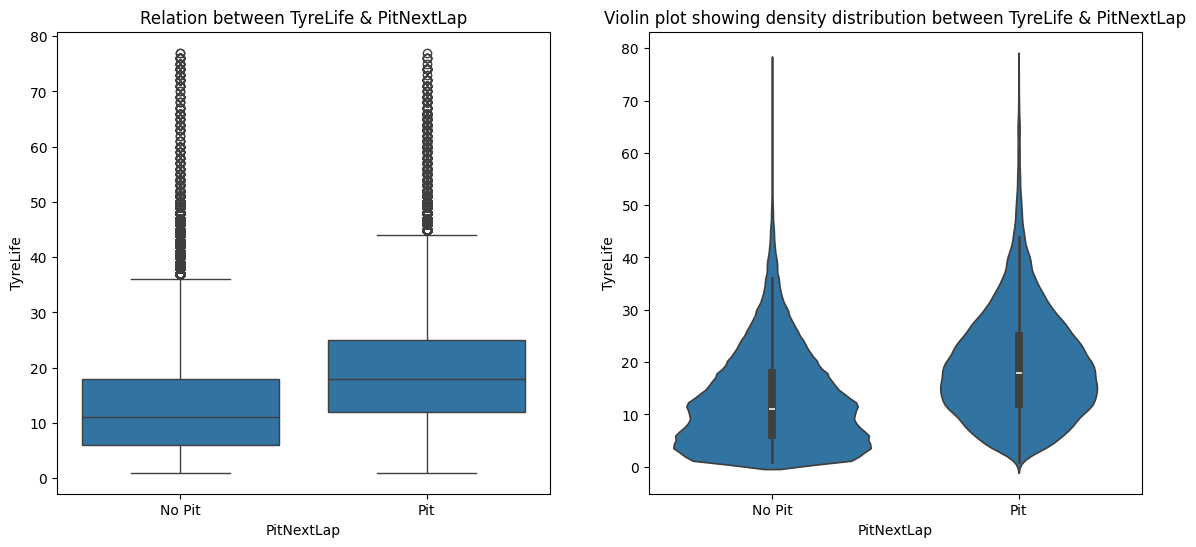

In [14]:
# again a numerical feature is plotted against categorical target
# therefore plotting the best plots for this strategy, boxplot and violinplot

fig,axes = plt.subplots(1,2,figsize=(14,6))

sb.boxplot(data=df,x='PitNextLap',y='TyreLife',ax=axes[0])
axes[0].set_title("Relation between TyreLife & PitNextLap")
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['No Pit','Pit'])

sb.violinplot(data=df,x='PitNextLap',y='TyreLife',ax=axes[1])
axes[1].set_title("Violin plot showing density distribution between TyreLife & PitNextLap")
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(["No Pit","Pit"])
plt.show()


#### **TyreLife – Number of laps on current tire**

***Obeservations:-*** 

**1. Central Tendency & Spread**

- Pit laps have a noticeably higher median TyreLife (~18 laps) compared to No Pit (~12 laps), which makes intuitive sense — drivers tend to pit after the tyre has been on for longer time.
- The IQR is wider for Pit (~15–25) vs No Pit (~8–17), meaning pit stop decisions happen across a broader range of tyre ages.

**2. Distribution Shape (Violin Plot)**

- No Pit shows a very fat bulge near 0–10 laps — most "no pit" observations cluster at low tyre ages, which is expected since fresh tyres rarely trigger a pit call.
- Pit has a more balanced, symmetrical belly centered around 15–25 laps, suggesting a fairly consistent tyre degradation window when pits are called.
- Both distributions have long upper tails, but No Pit's tail is heavier — some cars go extremely long stints without pitting (safety cars, strategy outliers).

**3. Outliers**

- No Pit has substantially more outliers at high TyreLife values (dots above ~40), indicating edge cases where drivers run very old tyres but still don't pit that lap.
- Pit outliers exist too but are fewer and more bounded (~45–75 range).

#### 3.2.3 Relationship between **Driver's Position** and **Next-Lap Pit** Decisions

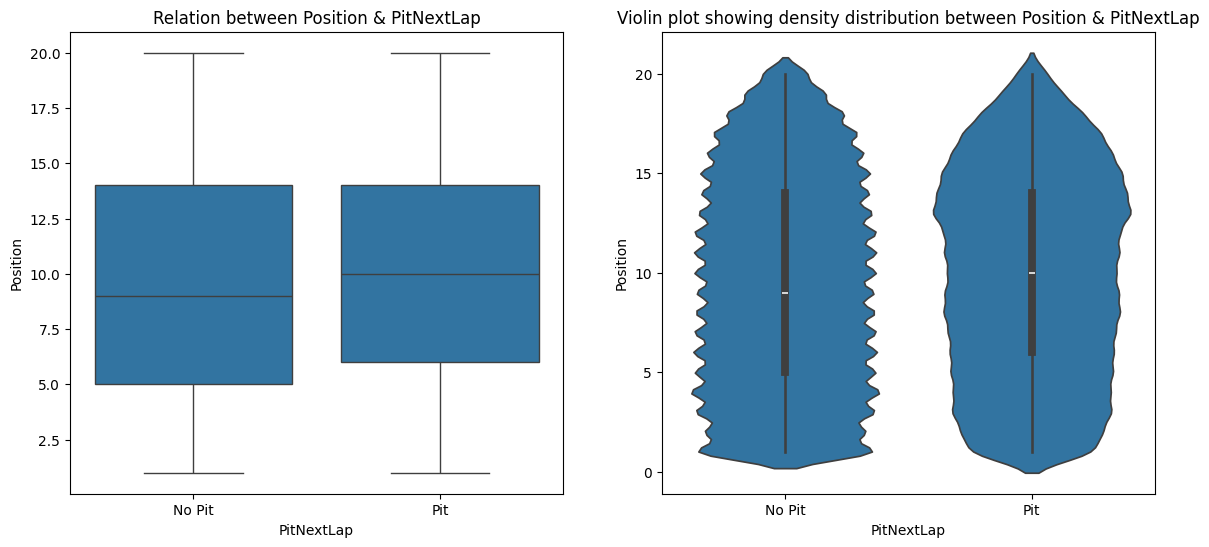

In [15]:
fig,axes = plt.subplots(1,2,figsize=(14,6))

sb.boxplot(data=df,x='PitNextLap',y='Position',ax=axes[0])
axes[0].set_title("Relation between Position & PitNextLap")
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['No Pit','Pit'])

sb.violinplot(data=df,x='PitNextLap',y='Position',ax=axes[1])
axes[1].set_title("Violin plot showing density distribution between Position & PitNextLap")
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(["No Pit","Pit"])
plt.show()

#### **Position – Driver’s position on that lap**
***Observations:-***

**1. Central Tendency & Spread**

- Medians are very close — No Pit ~9 vs Pit ~10 — an almost negligible difference.
- IQRs are nearly identical too (~5–14 for No Pit, ~6–14 for Pit), confirming that position alone barely distinguishes pit from non-pit laps.
- This is the weakest class separation seen so far compared to TyreLife and LapNumber.

***2. Distribution Shape (Violin Plot)**

- Both violins are broad and leaf-shaped, spanning nearly the full 1–20 position range — meaning pit stops happen at all grid positions with roughly equal probability.
- The jagged/serrated edges on the violin are a KDE artifact from the discrete nature of Position (it's an integer 1–20), not a real pattern — worth noting for presentation.
- No Pit has a slight bulge in the lower positions (1–8), suggesting front-runners are slightly less likely to pit on any given lap — possibly because they have more to lose from pitting.
- Pit is marginally fuller in the mid-to-back positions (10–16), hinting that midfield/backmarker teams may pit slightly more freely.

**3. Outliers**

- No extreme outliers in either class — Position is naturally bounded (1–20), so the distributions are clean with no tail concerns.

#### 3.2.4 Relationship between **LapTime in seconds** and **Next-Lap Pit** Decisions

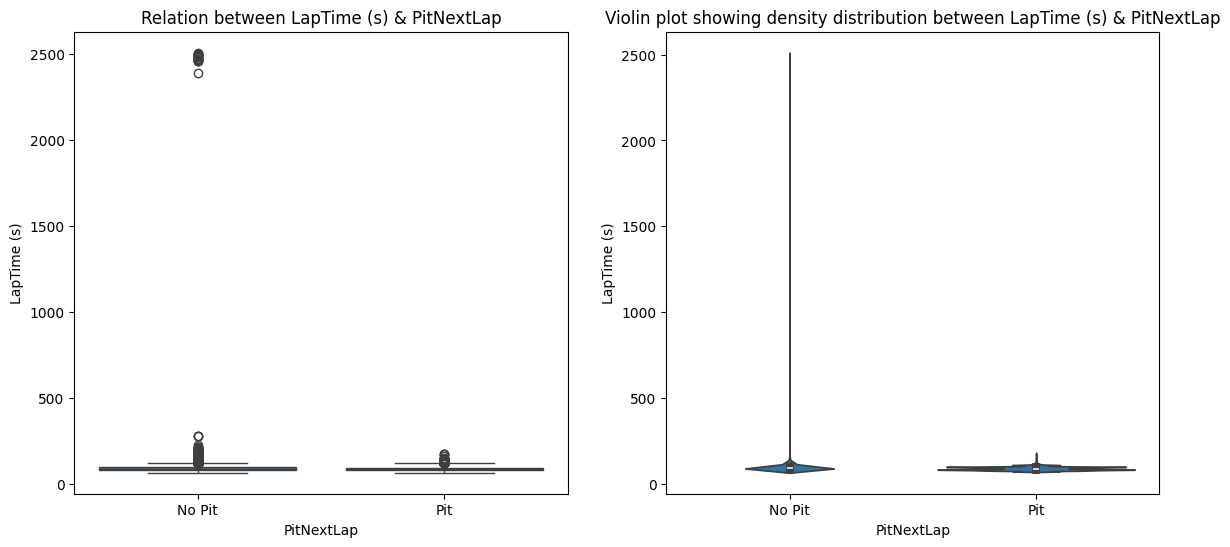

In [18]:
fig,axes = plt.subplots(1,2,figsize=(14,6))

sb.boxplot(data=df,x='PitNextLap',y='LapTime (s)',ax=axes[0])
axes[0].set_title("Relation between LapTime (s) & PitNextLap")
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['No Pit','Pit'])

sb.violinplot(data=df,x='PitNextLap',y='LapTime (s)',ax=axes[1])
axes[1].set_title("Violin plot showing density distribution between LapTime (s) & PitNextLap")
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(["No Pit","Pit"])
plt.show()

***Initial Observations:-***
- The plots are severely distorted by extreme outliers. 
- The y-axis stretches to 2500s, compressing virtually all real data into a thin strip near the bottom. A lap time of 2500 seconds (~41 minutes) is physically impossible in F1 — these are almost certainly data quality issues: formation laps, red flag periods, or missing/corrupt entries.
- Therefore i need to cap the y-axis (e.g., to ~200s) or remove outliers before visualizing.
- The current plots are not presentation-ready.

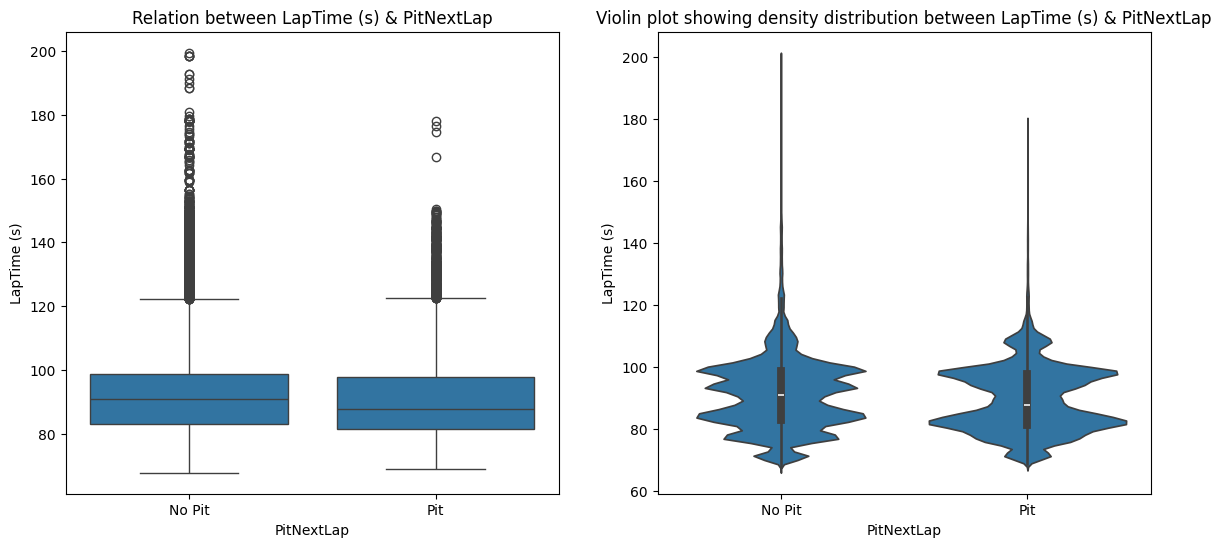

In [ ]:
df_clean = df[df['LapTime (s)'] < 200]
fig,axes = plt.subplots(1,2,figsize=(14,6))

sb.boxplot(data=df_clean,x='PitNextLap',y='LapTime (s)',ax=axes[0])
axes[0].set_title("Relation between LapTime (s) & PitNextLap")
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['No Pit','Pit'])

sb.violinplot(data=df_clean,x='PitNextLap',y='LapTime (s)',ax=axes[1])
axes[1].set_title("Violin plot showing density distribution between LapTime (s) & PitNextLap")
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(["No Pit","Pit"])
plt.show()

#### **LapTime (s) – Lap time in seconds**
***Final Observations:-***

**1. Central Tendency & Spread**

- No Pit median (~91s) is slightly higher than Pit (~88s) — a small but potentially meaningful difference.
- IQRs overlap heavily (~83–97 for No Pit, ~82–95 for Pit), so the separation is narrow.

**2. Distribution Shape (Violin Plot)**

- Both violins share a jagged, multi-lobed shape — this reflects the discrete nature of different circuits, each with its own characteristic lap time range, creating natural clusters in the data.
- No Pit violin is noticeably wider and fuller, consistent with it being the majority class with more data density.
- Pit violin is narrower and more compact in its core band (~80–100s), suggesting pit laps cluster tighter around "normal" racing pace.
- Both show a sharp spike/bulge around 110–120s — likely a specific slow circuit or safety car laps within the 200s cutoff.

**3. The Counterintuitive Median Finding**
The slight speed advantage on Pit laps likely reflects:

- Drivers on fresher compounds pitting later tend to have better pace right before stopping.
- Strategic in-laps where drivers push hard to maximise track position before the pit window.
- Alternatively, No Pit laps include more degraded-tyre laps across a wider range of race phases, pulling the median up.

**4. Outliers**

- No Pit has significantly more outliers above ~130s — VSC laps, safety car bunching, or slow circuits still present even after the 200s cap.
- Pit outliers are fewer and cap around ~175s — in-laps can be slow if a driver is managing a damaged car or pitting under yellow flags.

#### 3.2.5 Relationship between **Change in LapTime from previous lap** and **Next-Lap Pit** Decisions

[Text(0, 0, 'No Pit'), Text(1, 0, 'Pit')]

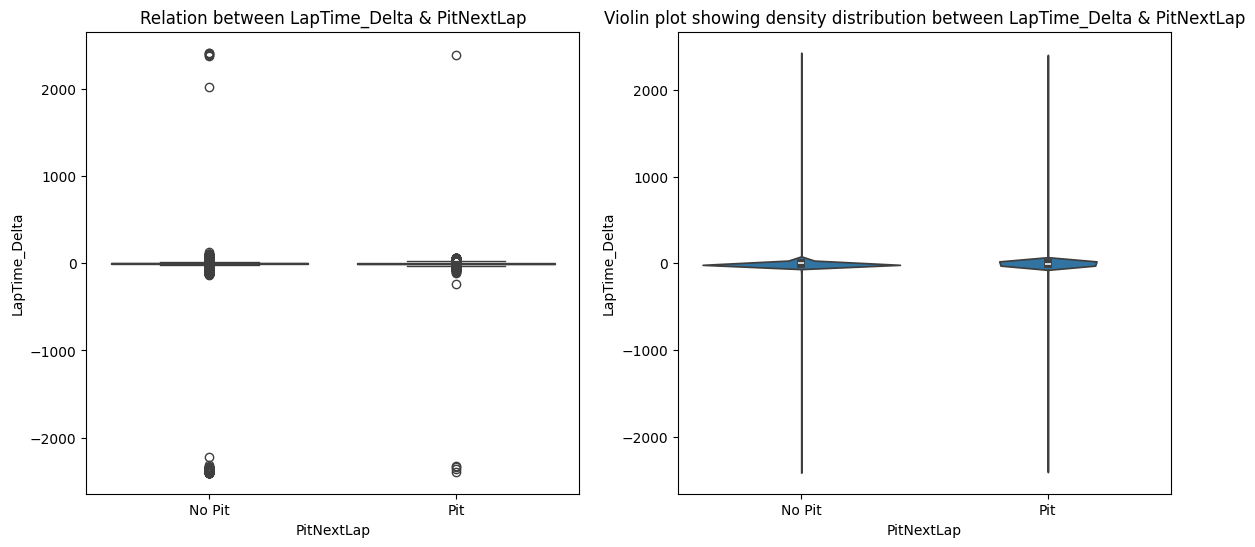

In [ ]:
fig,axes = plt.subplots(1,2,figsize=(14,6))

sb.boxplot(data=df_clean,x='PitNextLap',y='LapTime_Delta',ax=axes[0])
axes[0].set_title("Relation between LapTime_Delta & PitNextLap")
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['No Pit','Pit'])

sb.violinplot(data=df_clean,x='PitNextLap',y='LapTime_Delta',ax=axes[1])
axes[1].set_title("Violin plot showing density distribution between LapTime_Delta & PitNextLap")
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(["No Pit","Pit"])
plt.show()

***Initial Observations:-***

- Again the plots are distorted by extreme outliers on both sides positive and negative side of laptime delta.
- Some Y values are ranging upto ~ 2500 seconds which is not possible in F1 races unless there is an extreme accidental case but in that case too, the drivers are excluded from the race. 
- Therefore, i need to scale down the Y axis to a nominal range where these plots can depict some meaningful patters.

- Before scaling the Laptime_Delta feature, i need more info about it, since i have the 0.25 quantile and the .75 quantile, let's find the IQR which i will take as a statistical measure to weed out the extreme outliers.

In [34]:
print(" 0.25 quantile Q1 :",df['LapTime_Delta'].quantile(0.25))  # 25% of laps are BELOW this value
print(" 0.75 quantile Q3 :",df['LapTime_Delta'].quantile(0.75))  # 75% of laps are BELOW this value

 0.25 quantile Q1 : -8.884
 0.75 quantile Q3 : 0.1149999999999948


**Calculating the IQR:**

**IQR = Interquartile Range — the distance between Q1 and Q3.**

- It represents the middle 50% of the data — the range where the "typical" values live, completely ignoring the extremes on both ends.

- It's considered robust because it doesn't care about extreme values at all when computing itself — unlike the mean or standard deviation which get pulled by outliers.

In [ ]:
q1 = df['LapTime_Delta'].quantile(0.25)
q3 = df['LapTime_Delta'].quantile(0.75)

IQR = q3-q1

lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR
print(lower,"\n",upper)

#Therefore, filtering out the extreme outliers based on the IQR ranges i calculated
df_clean_laptime_delta = df[(df["LapTime_Delta"] >= lower) & (df["LapTime_Delta"] <= upper)]

8.998999999999995


- Why Multiply by 1.5?
- This is **Tukey's Fence** — a rule developed by statistician John Tukey.
- The logic is:

Take the middle 50% spread (IQR)
Extend 1.5 times that spread outward from both Q1 and Q3
Anything beyond those fences is considered an outlier

- Why 1.5 specifically? For a normal distribution, this rule flags roughly the outermost 0.7% of data as outliers a threshold that has proven practically useful across decades of statistical work.
- It's a convention, not a law, but it's widely trusted.

- So any lap time below 22s or above 13s gets flagged as an outlier. A 2500s lap? Miles outside the fence — removed. An 12s lap? Comfortably inside — kept.

- Therefore, revised plot of data will be :

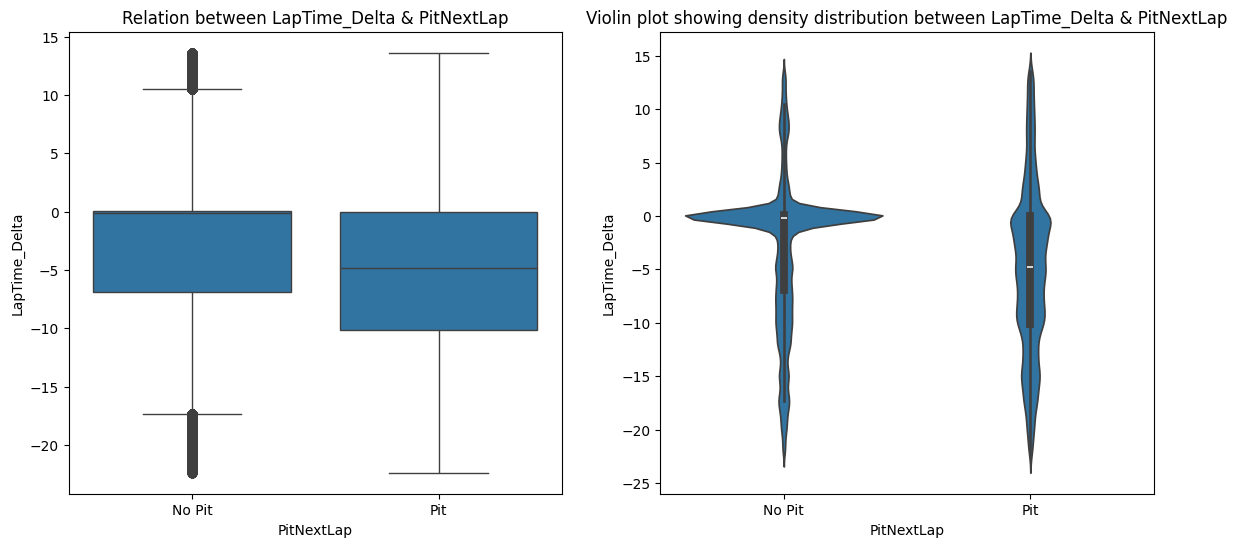

In [46]:
fig,axes = plt.subplots(1,2,figsize=(14,6))

sb.boxplot(data=df_clean_laptime_delta,x='PitNextLap',y='LapTime_Delta',ax=axes[0])
axes[0].set_title("Relation between LapTime_Delta & PitNextLap")
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['No Pit','Pit'])

sb.violinplot(data=df_clean_laptime_delta,x='PitNextLap',y='LapTime_Delta',ax=axes[1])
axes[1].set_title("Violin plot showing density distribution between LapTime_Delta & PitNextLap")
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(["No Pit","Pit"])
plt.show()

#### **LapTime (s) – Lap time in seconds**
***Final Observations:-***

**1. Central Tendency & Spread**

- No Pit median sits close to ~0 or just below, meaning non-pit laps cluster around a driver's baseline pace.
- Pit median is noticeably more negative (~-4 to -5s), meaning drivers tend to be running faster than their average on laps before they pit.
- The Pit IQR is substantially wider (~-10 to 0) vs No Pit (~-6 to 0), showing more variability in pace on pit laps.


**2. Distribution Shape (Violin Plot)**

- No Pit has a very sharp, narrow spike at 0 — the dominant mass of non-pit laps sit right at baseline pace, which makes complete sense; most laps are just normal racing laps.
- Pit violin is much fuller and elongated downward, with density spread well into the -10 to -15s range — drivers are meaningfully quicker before pitting.
- The asymmetric downward stretch of the Pit violin is the key visual signal here — it's not symmetric around 0, it's pulled negative.

**3. Outliers**

- No Pit has outliers on both sides — positive outliers (~+10 to +12s) likely represent VSC/SC laps or incidents; negative outliers (~-17 to -22s) are probably qualifying-style push laps or data anomalies.
- Pit outliers are mostly on the negative side (~-22 to -25s) — extreme push laps before pitting, possibly during undercut battles.

#### 3.2.6 Relationship between **Cummulative Degradation of Tyre** and **Next-Lap Pit** Decisions

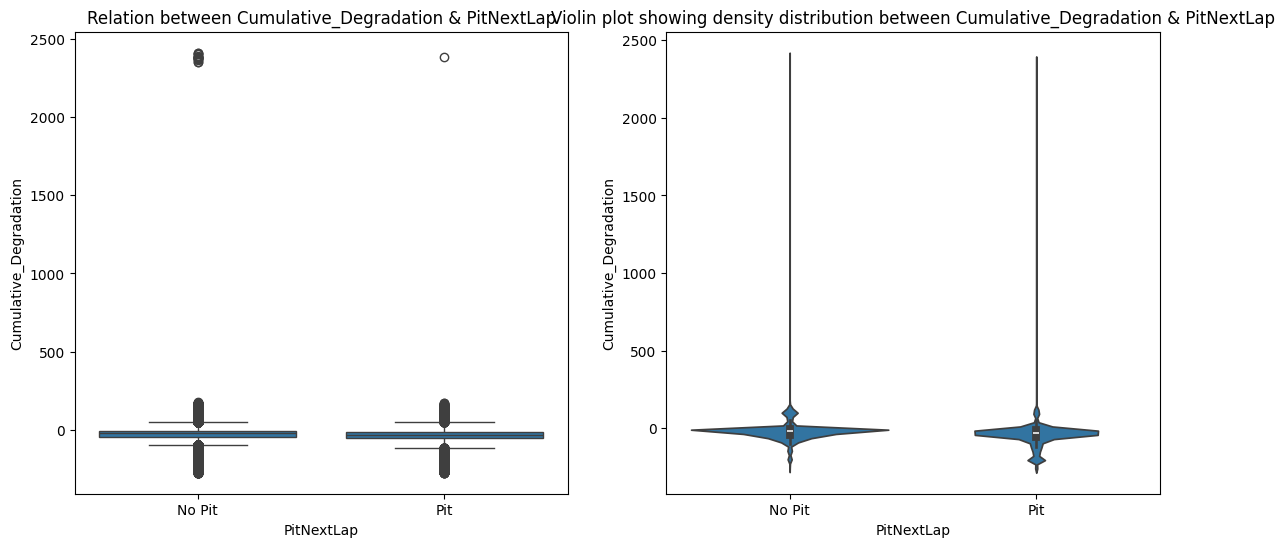

In [50]:
fig,axes = plt.subplots(1,2,figsize=(14,6))

sb.boxplot(data=df,x='PitNextLap',y='Cumulative_Degradation',ax=axes[0])
axes[0].set_title("Relation between Cumulative_Degradation & PitNextLap")
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['No Pit','Pit'])

sb.violinplot(data=df,x='PitNextLap',y='Cumulative_Degradation',ax=axes[1])
axes[1].set_title("Violin plot showing density distribution between Cumulative_Degradation & PitNextLap")
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(["No Pit","Pit"])
plt.show()

***Initial Observations:-***
- This plot is not analytically useful in its current state. The y-axis stretches to 2500, while virtually all real data is crushed into a thin band near 0.
- This is the same problem encountered with raw LapTime — extreme outliers are dominating the scale entirely.

- Therefore, weeding out the outliers is the most logical & immediate step required to further analyse this feature against the categorical target. I will again defer to IQR statistical measure for this purpose.

In [52]:
print(" 0.25 quantile Q1 :",df['Cumulative_Degradation'].quantile(0.25))  # 25% of laps are BELOW this value
print(" 0.75 quantile Q3 :",df['Cumulative_Degradation'].quantile(0.75))  # 75% of laps are BELOW this value

 0.25 quantile Q1 : -46.566250000000196
 0.75 quantile Q3 : -6.199000000000009


In [53]:
q1 = df['Cumulative_Degradation'].quantile(0.25)
q3 = df['Cumulative_Degradation'].quantile(0.75)

IQR = q3-q1

lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR
print(lower,"\n",upper)

#Therefore, filtering out the extreme outliers based on the IQR ranges i calculated
df_clean_cummulative_deg = df[(df["Cumulative_Degradation"] >= lower) & (df["Cumulative_Degradation"] <= upper)]

-107.11712500000047 
 54.35187500000026


- So any degradation value below 107 or above 54 gets flagged as an outlier. A 2400 data point? Miles outside the fence — removed. An 53 data point? Comfortably inside — kept.

- Therefore, revised distribution plot will be :

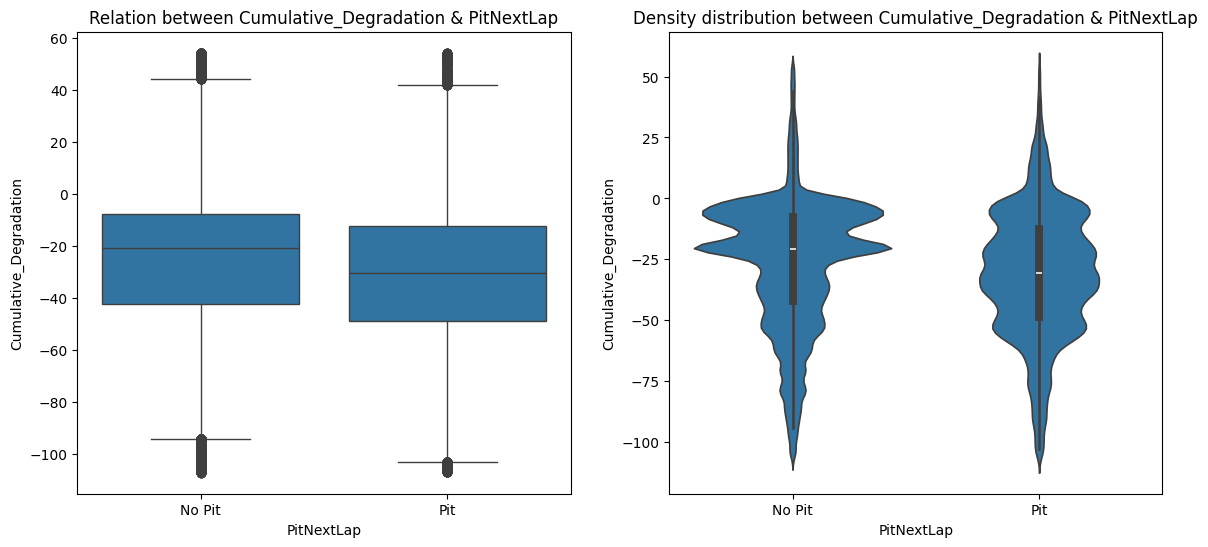

In [55]:
fig,axes = plt.subplots(1,2,figsize=(14,6))

sb.boxplot(data=df_clean_cummulative_deg,x='PitNextLap',y='Cumulative_Degradation',ax=axes[0])
axes[0].set_title("Relation between Cumulative_Degradation & PitNextLap")
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['No Pit','Pit'])

sb.violinplot(data=df_clean_cummulative_deg,x='PitNextLap',y='Cumulative_Degradation',ax=axes[1])
axes[1].set_title("Density distribution between Cumulative_Degradation & PitNextLap")
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(["No Pit","Pit"])
plt.show()

#### **Cumulative_Degradation – Accumulated tire performance drop**
***Final Observations:-***

***A Note on Negative Values***
- Before diving in — negative degradation is worth pausing on. Cumulative degradation being negative likely means this feature is computed as:

**Cumulative_Degradation = Cumulative LapTime - some reference (e.g., best lap × lap count)**

**So negative = driver is ahead of the degradation baseline, positive = behind it. I gotta keep this in mind when interpreting direction.**

**1. Central Tendency & Spread**

- No Pit median sits around ~-22s, while Pit median is slightly lower at ~-30s.
- This means Pit laps show greater cumulative degradation relative to baseline — drivers have accumulated more total time loss before pitting, which makes intuitive sense.
- Pit IQR is wider (~-50 to -15) vs No Pit (~-40 to -10), indicating more variability in how degraded tyres are when a pit call is made.


**2. Distribution Shape (Violin Plot)**

- No Pit violin has a clear bimodal structure — two distinct bulges around 0 to -10 and -20 to -30 — suggesting two behavioural clusters: laps with minimal degradation and laps with moderate degradation.
- Pit violin is unimodal and fuller, with density concentrated between -20 and -50 — a more consistent degradation profile when pitting occurs.
- Both violins have jagged edges similar to the Position plot — likely due to the discrete/circuit-clustered nature of the underlying data.
- No Pit has a notable bulge near 0, which is the fresh-tyre effect — early stint laps where degradation hasn't accumulated yet.


**3. Outliers**

- No Pit has outliers reaching ~+45 to +50 (positive degradation — unusually bad performance) and down to ~-105 (very efficient cumulative performance).
- Pit outliers are similar in range but slightly less extreme on the positive side, suggesting catastrophically degraded laps rarely trigger a pit immediately.

#### 3.2.7 Relationship between **Race Progression(0 → 1)** and **Next-Lap Pit** Decisions

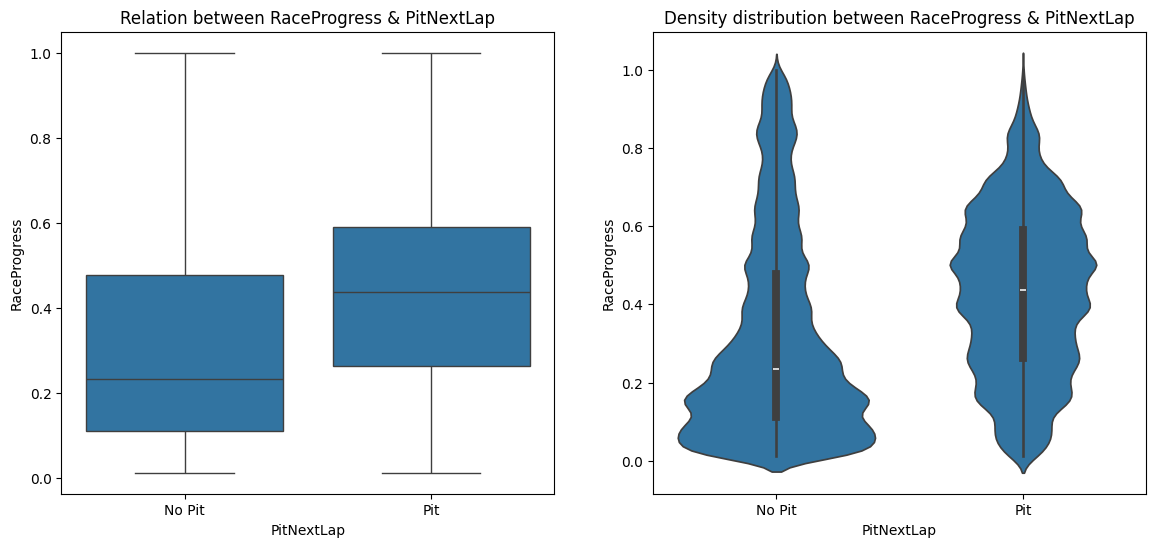

In [59]:
fig,axes = plt.subplots(1,2,figsize=(14,6))

sb.boxplot(data=df,x='PitNextLap',y='RaceProgress',ax=axes[0])
axes[0].set_title("Relation between RaceProgress & PitNextLap")
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['No Pit','Pit'])

sb.violinplot(data=df,x='PitNextLap',y='RaceProgress',ax=axes[1])
axes[1].set_title("Density distribution between RaceProgress & PitNextLap")
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(["No Pit","Pit"])
plt.show()

#### **RaceProgress – Fraction of race completed (0 → 1)**
***Observations:-***

- The feature is naturally bounded between 0 and 1 by design — there's no possibility of extreme outliers since it's a ratio.
- This is exactly why normalizing features like this is good practice. Clean data, clean plot, no preprocessing required.

**1. Central Tendency & Spread**

- No Pit median is notably lower at ~0.22–0.25, meaning most non-pit laps occur in the first quarter of the race.
- Pit median sits higher at ~0.44–0.46, placing pit stops firmly in the middle portion of the race.
- Pit IQR is wider (~0.30–0.60) vs No Pit (~0.13–0.48), showing pit stops are spread across a broader race window while non-pit laps are front-loaded.


**2. Distribution Shape (Violin Plot)**

- No Pit has a massive sharp spike near 0.0–0.10 — the largest density concentration of any feature seen so far — reflecting the simple reality that early race laps generate far more non-pit observations than any other phase.
- Moving upward, No Pit density gradually tapers but remains present all the way to 1.0, with a slight bulge around 0.60–0.70 — possibly a second stint where drivers are managing tyres rather than pitting.
- Pit violin is remarkably uniform and evenly distributed from ~0.15 to 0.75, with a fuller body — this suggests pit stops are spread fairly consistently across the middle two thirds of a race, which aligns perfectly with real F1 strategy windows.
- Both violins show jagged edges — same circuit-clustering artifact seen in previous features since RaceProgress inherits the discrete lap structure.


**3. The Sharp No Pit Spike Near 0**
This is the most striking visual feature of the plot. It tells a clear story:

- Lap 1 through ~10 generates enormous No Pit observations simply because nobody pits in the opening phase under normal conditions.
- This creates a heavy early-race concentration that no amount of tyre age or degradation would override.
- It's also a reminder of the class imbalance — No Pit dominates in volume, especially early in races.

**4. Outliers**

- Essentially none — the 0–1 bounded nature of the feature eliminates any possibility of extreme values
Both whiskers extend cleanly to 0.0 and 1.0 respectively, meaning the full race range is represented without anomalies.

#### 3.2.8 Relationship between **Change in position during race** and **Next-Lap Pit** Decisions

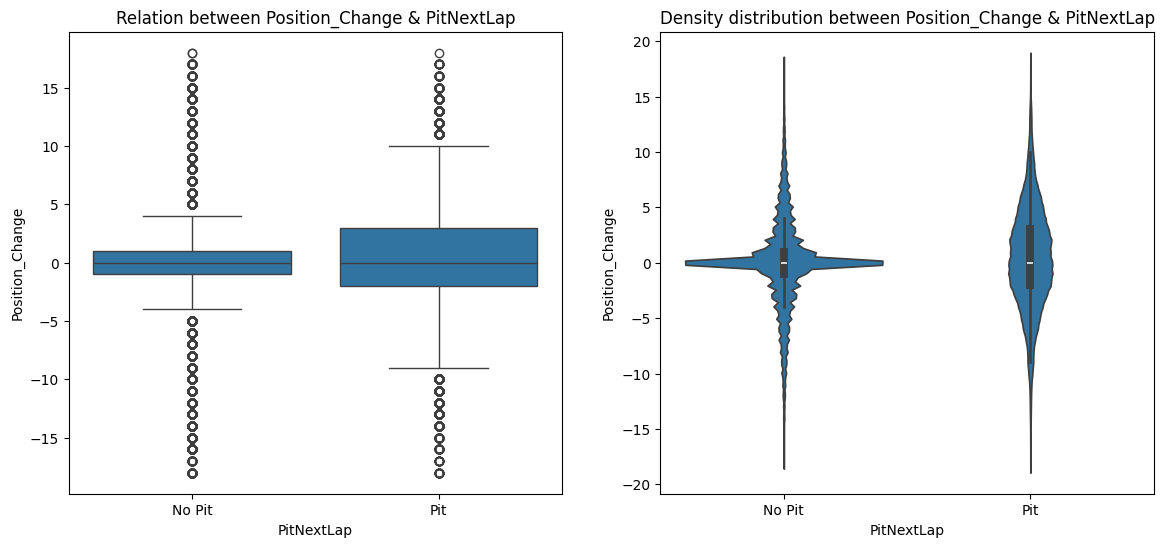

In [63]:
fig,axes = plt.subplots(1,2,figsize=(14,6))

sb.boxplot(data=df,x='PitNextLap',y='Position_Change',ax=axes[0])
axes[0].set_title("Relation between Position_Change & PitNextLap")
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['No Pit','Pit'])

sb.violinplot(data=df,x='PitNextLap',y='Position_Change',ax=axes[1])
axes[1].set_title("Density distribution between Position_Change & PitNextLap")
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(["No Pit","Pit"])
plt.show()

#### **Position_Change – Position gain/loss compared to previous lap**
***Observations:-***

- The sharp needle-like spike at 0 in both violins is not a plotting artifact — it's real and meaningful:

- On the vast majority of laps, drivers neither gain nor lose positions.
- This creates a massive density concentration at exactly 0.
- The wings spreading outward represent the rarer laps where positions actually change.
- This is called a zero-inflated distribution — a perfectly normal and recognizable pattern for change/delta features in racing data.


**1. Central Tendency & Spread**

- Both medians sit at ~0 — identical at first glance.
- However No Pit IQR is tighter (~-1 to +1) while Pit IQR is wider (~-2 to +3).
- This means more position volatility occurs on pit laps — which makes complete strategic sense, since pitting is often triggered by or causes position changes.

**2. Distribution Shape**

- No Pit — extremely tight, almost all mass at 0, very thin wings. Drivers holding position lap after lap, nothing happening.
- Pit — still centered at 0 but with meaningfully fatter wings, especially on the positive side (+1 to +4). This suggests pit stops are associated with gaining positions — consistent with undercut strategies working.
- The Pit violin bulges slightly more to the positive side than negative — an asymmetry worth noting, suggesting successful position gains are more common around pit laps than losses.


**3. Outliers**

- No Pit has heavy outliers on both sides reaching ±15 to ±17 — these are first-lap pile-ups, safety car restarts, or incidents causing massive position swings without a pit stop.
- Pit outliers are more bounded (~±10 to ±12) — extreme position swings during pit laps are rarer since the pit stop itself is the strategic event.

## 🏁 EDA Summary & Transition to Feature Engineering
### F1 Pit Stop Prediction · Exploratory Data Analysis Notebook
---

This notebook covered end-to-end exploratory analysis of the F1 pit stop dataset — from raw distribution profiling through bivariate analysis against the `PitNextLap` target. The findings below inform the feature engineering strategy in the next phase.

| Feature | Key finding | Engineering action | Priority |
|---|---|---|---|
| `TyreLife` | Strong separator — higher values → pit likely | Clip outliers (IQR); consider binning into stint phases | 🔴 High |
| `LapNumber` | Non-linear pit tendency; late-race peaks visible | Add race-progress ratio: `LapNumber / TotalLaps` | 🔴 High |
| `Position` | Mid-field drivers pit more opportunistically | Retain as-is; consider positional gap delta features | 🟡 Medium |
| `LapTime` | Degraded tyres visible as lap time drift | Compute rolling delta (`ΔLapTime` vs personal best) | 🔴 High |

---

**Next notebook → `03_feature_engineering.ipynb`**

Planned steps: outlier treatment · tyre phase encoding · rolling lap time delta · race progress ratio · class imbalance audit on `PitNextLap`

> ℹ️ All raw data is preserved — transformations will be applied only in the feature engineering notebook to keep this EDA fully reproducible.